# Kalman Filter Pairs Trading Showcase

This notebook estimates a dynamic hedge ratio with a Kalman filter and trades mean reversion
using the normalized innovation signal (`innovation / sqrt(spread_var)`).

- `MODE = "live"`: pull latest data from yfinance
- `MODE = "cache"`: use local cached CSV/parquet data
- Pair scan applies `pvalue <= 0.05` by default
- Run the dependency bootstrap cell first (next cell), then run the notebook top-to-bottom


In [1]:
from __future__ import annotations

import importlib.util
import subprocess
import sys

REQUIRED = {
    'numpy': 'numpy>=1.24',
    'pandas': 'pandas>=2.0',
    'matplotlib': 'matplotlib>=3.7',
    'yfinance': 'yfinance>=0.2.40',
    'statsmodels': 'statsmodels>=0.14',
}

missing = [pkg for module, pkg in REQUIRED.items() if importlib.util.find_spec(module) is None]
if missing:
    print('Installing missing packages into this notebook kernel:')
    print('  ' + ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('All required packages are already installed.')


All required packages are already installed.


In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
PROJECT_ROOT = ROOT if (ROOT / 'src').exists() else ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from kalman_pairs.backtest import run_backtest
from kalman_pairs.data import fetch_prices
from kalman_pairs.kalman import KalmanHedgeModel
from kalman_pairs.pair_selection import rank_pairs
from kalman_pairs.signals import compute_normalized_innovation, generate_positions

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)


In [3]:
# Configuration
MODE = 'live'  # use 'cache' for fully offline reproducible runs
INTERVAL = '1d'
START_DATE = '2023-01-01'
END_DATE = pd.Timestamp.today().strftime('%Y-%m-%d')
CACHE_DIR = PROJECT_ROOT / 'data' / 'cache'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

UNIVERSE = ['XLF', 'JPM', 'BAC', 'WFC', 'C', 'GS', 'MS']
TOP_N = 5
MIN_HISTORY = 252
PVALUE_MAX = 0.05

PROCESS_VAR = 1e-4
OBS_VAR = 1e-2
SIGNAL_CLIP = 6.0
ENTRY_Z = 2.0
EXIT_Z = 0.5
STOP_Z = 3.5
MAX_HOLD = 20
COSTS_BPS = 2.0
FORCE_REFRESH = True


In [4]:
if MODE == 'live':
    prices = fetch_prices(
        tickers=UNIVERSE,
        start=START_DATE,
        end=END_DATE,
        interval=INTERVAL,
        source='yfinance',
        force_refresh=FORCE_REFRESH,
        cache_dir=CACHE_DIR,
    )
else:
    prices = fetch_prices(
        tickers=UNIVERSE,
        start=START_DATE,
        end=END_DATE,
        interval=INTERVAL,
        source='cache',
        cache_dir=CACHE_DIR,
    )

print(f'Loaded prices with shape: {prices.shape}')
prices.tail()


Loaded prices with shape: (796, 7)


,XLF,JPM,BAC,WFC,C,GS,MS
Date,,,,,,,
2026-03-02,51.299999,297.559998,49.530003,82.580002,111.449997,861.700012,167.000000
2026-03-03,51.209999,300.260010,49.689102,82.529999,110.760002,862.580017,165.949997
2026-03-04,51.500000,299.390015,50.017242,83.930000,111.320000,867.250000,167.580002
2026-03-05,51.230000,293.549988,49.530003,82.110001,108.949997,835.460022,162.550003
2026-03-06,50.570000,289.480011,48.639999,80.419998,106.529999,821.419983,160.270004


In [5]:
ranked_pairs = rank_pairs(
    prices,
    top_n=TOP_N,
    min_history=MIN_HISTORY,
    max_pvalue=PVALUE_MAX,
)
if ranked_pairs.empty:
    raise RuntimeError('No valid pairs found after p-value filter. Relax PVALUE_MAX or expand universe.')

selected = ranked_pairs.iloc[0]
Y_TICKER = selected['y']
X_TICKER = selected['x']

print('Top ranked pairs (filtered by p-value):')
display(ranked_pairs)
print(f'Selected pair: y={Y_TICKER}, x={X_TICKER}, pvalue={selected["pvalue"]:.4f}')


Top ranked pairs (filtered by p-value):


,y,x,n_obs,pvalue,alpha,beta,spread_std,spread_autocorr,mean_reversion_speed,score
0,JPM,WFC,796,0.01268,-6.154703,3.602278,10.164117,0.964114,0.035886,0.70189


Selected pair: y=JPM, x=WFC, pvalue=0.0127


In [6]:
y = prices[Y_TICKER]
x = prices[X_TICKER]

model = KalmanHedgeModel(process_var=PROCESS_VAR, obs_var=OBS_VAR)
state_df = model.fit(y, x)

state_df.tail()


,alpha,beta,spread,spread_var,innovation,gain_alpha,gain_beta
Date,,,,,,,
2026-03-02,35.017347,3.180335,-0.089434,0.702275,-6.280748,-0.010822,0.012068
2026-03-03,35.018728,3.213399,0.039506,0.701066,2.769604,0.000499,0.011938
2026-03-04,35.091641,3.149909,-0.073518,0.724889,-5.329252,-0.013682,0.011913
2026-03-05,35.088314,3.147781,-0.002604,0.694016,-0.180711,0.018411,0.011779
2026-03-06,35.111586,3.162767,0.018711,0.666550,1.247176,0.018660,0.012016


In [7]:
signal = compute_normalized_innovation(
    state_df['innovation'],
    state_df['spread_var'],
    clip=SIGNAL_CLIP,
)
positions = generate_positions(
    signal,
    entry=ENTRY_Z,
    exit=EXIT_Z,
    stop=STOP_Z,
    max_hold=MAX_HOLD,
)

aligned_y = y.loc[state_df.index]
aligned_x = x.loc[state_df.index]

results = run_backtest(
    y=aligned_y,
    x=aligned_x,
    beta_t=state_df['beta'],
    positions=positions,
    costs_bps=COSTS_BPS,
)

metrics = pd.Series(results['metrics'], name='value')
display(metrics.to_frame())


,value
Sharpe,-0.156576
max_drawdown,-0.800855
hit_rate,0.478555
turnover,0.424623
total_return,-0.524632
trades,338.000000


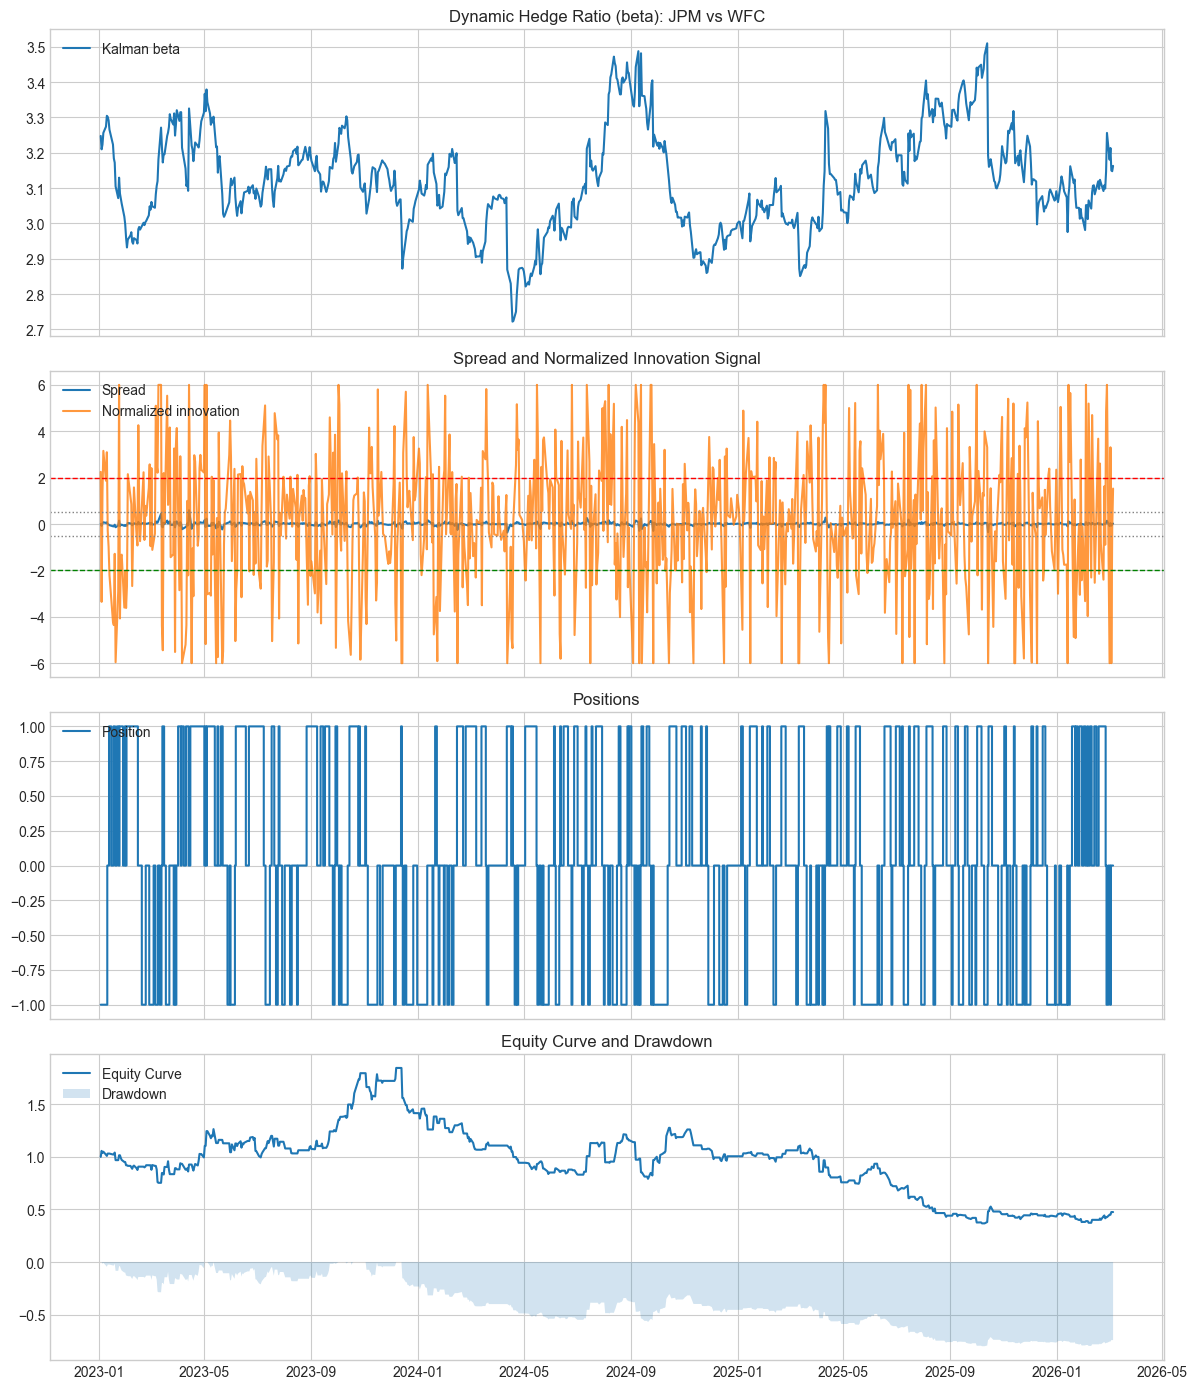

In [8]:
equity = results['equity_curve']

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

axes[0].plot(state_df.index, state_df['beta'], label='Kalman beta')
axes[0].set_title(f'Dynamic Hedge Ratio (beta): {Y_TICKER} vs {X_TICKER}')
axes[0].legend(loc='upper left')

axes[1].plot(state_df.index, state_df['spread'], label='Spread')
axes[1].plot(signal.index, signal, label='Normalized innovation', alpha=0.8)
axes[1].axhline(ENTRY_Z, color='red', linestyle='--', linewidth=1)
axes[1].axhline(-ENTRY_Z, color='green', linestyle='--', linewidth=1)
axes[1].axhline(EXIT_Z, color='gray', linestyle=':', linewidth=1)
axes[1].axhline(-EXIT_Z, color='gray', linestyle=':', linewidth=1)
axes[1].set_title('Spread and Normalized Innovation Signal')
axes[1].legend(loc='upper left')

axes[2].step(positions.index, positions, where='mid', label='Position')
axes[2].set_title('Positions')
axes[2].legend(loc='upper left')

axes[3].plot(equity.index, equity['equity_curve'], label='Equity Curve')
axes[3].fill_between(equity.index, equity['drawdown'], 0, alpha=0.2, label='Drawdown')
axes[3].set_title('Equity Curve and Drawdown')
axes[3].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ranked_pairs.to_csv(OUTPUT_DIR / 'selected_pairs.csv', index=False)
results['trades'].to_csv(OUTPUT_DIR / 'trades.csv', index=True)
results['equity_curve'].to_csv(OUTPUT_DIR / 'equity_curve.csv', index=True)

print('Exported artifacts:')
print(OUTPUT_DIR / 'selected_pairs.csv')
print(OUTPUT_DIR / 'trades.csv')
print(OUTPUT_DIR / 'equity_curve.csv')


Exported artifacts:
/Users/user/Documents/GitHub/kalmanFilterNotebook/outputs/selected_pairs.csv
/Users/user/Documents/GitHub/kalmanFilterNotebook/outputs/trades.csv
/Users/user/Documents/GitHub/kalmanFilterNotebook/outputs/equity_curve.csv


In [10]:
if MODE != 'live':
    print('Live refresh skipped because MODE is not live.')
else:
    latest = fetch_prices(
        tickers=[Y_TICKER, X_TICKER],
        start=(pd.Timestamp(END_DATE) - pd.Timedelta(days=10)).strftime('%Y-%m-%d'),
        end=pd.Timestamp.today().strftime('%Y-%m-%d'),
        interval=INTERVAL,
        source='yfinance',
        force_refresh=True,
        cache_dir=CACHE_DIR,
    )

    y_t = float(latest[Y_TICKER].iloc[-1])
    x_t = float(latest[X_TICKER].iloc[-1])
    update = model.update_one(y_t=y_t, x_t=x_t)

    live_signal = float(update['innovation'] / np.sqrt(max(update['spread_var'], 1e-12)))

    print('Latest live state update:')
    print({
        'timestamp': str(latest.index[-1]),
        'alpha': round(update['alpha'], 6),
        'beta': round(update['beta'], 6),
        'spread': round(update['spread'], 6),
        'innovation': round(update['innovation'], 6),
        'spread_var': round(update['spread_var'], 6),
        'live_signal': round(live_signal, 6),
    })


Latest live state update:
{'timestamp': '2026-03-06 00:00:00', 'alpha': 35.111594, 'beta': 3.162996, 'spread': 0.000281, 'innovation': 0.018711, 'spread_var': 0.666688, 'live_signal': 0.022916}
